# 02 — Training: Layer 2 (Macro Topic) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 2 — Macro Topic (6 classes: `TOPIC_ECON`, `TOPIC_GOV`, `TOPIC_SERV`, `TOPIC_LAW`, `TOPIC_FOR`, `TOPIC_MEDIA`) |
| **Notebook role** | Fine-tuning only — data prep and final evaluation happen elsewhere |
| **Owner** | [Your name] |
| **Upstream input** | `data/splits/layer2/train.csv` (oversampled), `val.csv` (untouched) — from `01_data_preparation.ipynb` |
| **Downstream consumer** | `03_evaluation.ipynb` — uses this notebook's checkpoint against the still-untouched test set |
| **Base model** | `xlm-roberta-base`, 6-way classification head |
| **Random seed** | 42 |

## Purpose

Fine-tunes `xlm-roberta-base` into a 6-class topic classifier using the oversampled
training data and a corrected class-weighting strategy (see Section 6). Does not touch
`data/splits/layer2/test.csv`. Metrics shown here are validation-set sanity checks only.

## How to Read This Notebook

Written assuming no prior context. Two things carried forward from `01_data_preparation.ipynb`
and from `06_layer1_utility/02_training.ipynb`: no claim of 100% accuracy is made anywhere
in this pipeline, and per-class metrics are reported honestly rather than relying on
aggregate accuracy — critical for this layer specifically, since `TOPIC_GOV`'s 82%
dominance in the raw data means a model that ignores every other topic could still look
deceptively accurate.

**A correction from `01_data_preparation.ipynb`'s handover notes, addressed in Section 6:**
that notebook computed class weights from the *pre-oversampling* distribution and
suggested applying them on top of the *oversampled* training set. Doing so would
double-correct the same imbalance — once through duplication, again through loss
weighting — risking unstable gradients on the most heavily duplicated classes. This
notebook computes weights correctly, from the actual post-oversampling distribution the
model trains on.

## 0. Google Colab Setup — Environment & Google Drive

This notebook is configured to run in **Google Colab with a GPU runtime**, reading project
files from **Google Drive**. Before running anything below:

1. **Runtime → Change runtime type → GPU** (T4 is fine) — do this first, before running any cell.
2. Run the two setup cells below **in order**, then follow the restart instruction exactly
   — skipping the restart is the most common cause of import errors in this notebook.

**Why the package install below looks the way it does:** running this same pipeline
earlier surfaced a real conflict — pinning `transformers` pulls in a newer `torch` than
Colab's preinstalled `torchvision` was built against, causing a
`torchvision::nms does not exist` error that cascades into `Trainer` failing to import.
The fix is to remove `torchvision`/`torchaudio` entirely, since this project only does
text classification and never imports either.

In [19]:
# Remove torchvision/torchaudio -- this project never uses them, and an incompatible
# version left installed alongside a pinned transformers/torch causes import failures.
!pip uninstall -y torchvision torchaudio -q

# Pin transformers to the version verified to work in this project's Colab environment.
# torch itself is left as Colab's preinstalled version -- do not reinstall it separately.
!pip install -q transformers==4.53.0 datasets accelerate sentencepiece "scikit-learn>=1.4"

print("Install complete.")
print()
print("REQUIRED NEXT STEP: Runtime -> Restart session, then Runtime -> Run all from the top.")
print("A plain re-run of cells is NOT enough -- old library versions may still be loaded in memory.")

Install complete.

REQUIRED NEXT STEP: Runtime -> Restart session, then Runtime -> Run all from the top.
A plain re-run of cells is NOT enough -- old library versions may still be loaded in memory.


**Stop here and restart the runtime now** (Runtime → Restart session), then use
**Runtime → Run all** to execute from the top in a clean process. Continuing without
restarting risks the exact `torchvision::nms` error described above.

In [20]:
# Verify the environment is correct BEFORE mounting Drive or loading any project data --
# catches a skipped restart immediately with a clear message instead of a confusing failure later.
import torch
import transformers

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
assert transformers.__version__ == "4.53.0", (
    f"Expected transformers 4.53.0, found {transformers.__version__} -- "
    f"did you Restart session after the install cell above?"
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
print("Core imports successful -- no torchvision conflict.")

print("\nCUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("WARNING: No GPU detected. Go to Runtime -> Change runtime type -> GPU and re-run.")

torch: 2.11.0+cu128
transformers: 4.53.0
Core imports successful -- no torchvision conflict.

CUDA available: True


### Mount Google Drive & Locate the Project

Update `PROJECT_ROOT` below if your uploaded folder has a different name than
`public-pulse-srilanka`.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/public-pulse-srilanka-main")

assert PROJECT_ROOT.exists(), (
    f"Project folder not found at {PROJECT_ROOT} -- check the folder name in your Drive "
    f"and update PROJECT_ROOT above if it differs."
)
print("Project root:", PROJECT_ROOT.resolve())
print("Contents:")
for item in sorted(PROJECT_ROOT.iterdir()):
    print(" -", item.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/public-pulse-srilanka-main
Contents:
 - .github
 - .gitignore
 - Dockerfile
 - README.md
 - api
 - configs
 - dashboard
 - data
 - deployment
 - docs
 - models
 - notebooks
 - pyproject.toml
 - requirements.txt
 - results
 - scripts
 - src
 - tests


In [22]:
# Confirm Layer 2's specific inputs exist before proceeding -- fails clearly here
# rather than deep inside a pandas read_csv call later.
splits_check = PROJECT_ROOT / "data" / "splits" / "layer2"
train_check = splits_check / "train.csv"

print("Layer 2 splits directory:", splits_check)
print("Exists:", splits_check.exists())
print("train.csv exists:", train_check.exists())

if not train_check.exists():
    print("\nWARNING: train.csv not found. Make sure you uploaded your project folder to ")
    print("Drive AFTER running 01_data_preparation.ipynb locally, or run that notebook ")
    print("in Colab first to generate data/splits/layer2/.")

Layer 2 splits directory: /content/drive/MyDrive/public-pulse-srilanka-main/data/splits/layer2
Exists: True
train.csv exists: True


## 1. Compute Requirements & Environment

Same guidance as the Layer 1 training notebook: fine-tuning is meaningfully more
compute-intensive than the inference/data-prep work elsewhere in this project. If no GPU
is detected below, strongly consider Google Colab (free T4 GPU) or Kaggle rather than
running the full training loop on CPU.

In [23]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device detected: {device}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU detected. Training will be slow on CPU -- consider Colab/Kaggle.")

Device detected: cuda
GPU: Tesla T4


## 2. Setup, Imports & Reproducibility

In [24]:
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

# PROJECT_ROOT is already defined above by the Google Drive mount cell (Section 0)
SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer2"
MODEL_DIR = PROJECT_ROOT / "models" / "layer2_topic"
CHECKPOINTS_DIR = MODEL_DIR / "checkpoints"
RUN_OUTPUT_DIR = MODEL_DIR / "_training_run"
RESULTS_TRAINING_DIR = PROJECT_ROOT / "results" / "training_curves"
RESULTS_CM_DIR = PROJECT_ROOT / "results" / "confusion_matrices"

for d in [CHECKPOINTS_DIR, RUN_OUTPUT_DIR, RESULTS_TRAINING_DIR, RESULTS_CM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "xlm-roberta-base"
MAX_SEQ_LENGTH = 256  # validated against this text pool in both Layer 1 and Layer 2 data-prep notebooks

print("Train/val source:", SPLITS_DIR.resolve())

Train/val source: /content/drive/MyDrive/public-pulse-srilanka-main/data/splits/layer2


## 3. Load Prepared Data (from `01_data_preparation.ipynb`)

`train.csv` already contains the capped oversampling applied in data preparation —
this notebook does not re-sample or modify it further. `val.csv` is untouched.

In [25]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "val.csv")

LAYER2_LABELS = sorted(train_df["layer2_topic_label"].unique())

print(f"Train: {len(train_df)} rows (oversampled)")
print(f"Val:   {len(val_df)} rows (untouched)")
print()
print("Train class distribution:")
print(train_df["layer2_topic_label"].value_counts())
print()
print("Val class distribution:")
print(val_df["layer2_topic_label"].value_counts())

assert train_df["layer2_topic_label"].isna().sum() == 0, "Missing labels in train set"
assert val_df["layer2_topic_label"].isna().sum() == 0, "Missing labels in val set"
assert len(LAYER2_LABELS) == 6, f"Expected 6 topic classes, found {len(LAYER2_LABELS)}: {LAYER2_LABELS}"
print("\nUpstream data contract verified: 6 classes, no missing labels.")

Train: 6155 rows (oversampled)
Val:   1153 rows (untouched)

Train class distribution:
layer2_topic_label
TOPIC_GOV      4433
TOPIC_LAW       400
TOPIC_FOR       400
TOPIC_MEDIA     400
TOPIC_ECON      321
TOPIC_SERV      201
Name: count, dtype: int64

Val class distribution:
layer2_topic_label
TOPIC_GOV      950
TOPIC_LAW       68
TOPIC_MEDIA     58
TOPIC_FOR       40
TOPIC_ECON      23
TOPIC_SERV      14
Name: count, dtype: int64

Upstream data contract verified: 6 classes, no missing labels.


## 4. Label Encoding

In [26]:
label2id = {label: idx for idx, label in enumerate(LAYER2_LABELS)}
id2label = {idx: label for label, idx in label2id.items()}

with open(MODEL_DIR / "label_map.json", "w") as f:
    json.dump(label2id, f, indent=2)

print("Label map:", label2id)
print("Saved to:", MODEL_DIR / "label_map.json")

train_df["label"] = train_df["layer2_topic_label"].map(label2id)
val_df["label"] = val_df["layer2_topic_label"].map(label2id)

Label map: {'TOPIC_ECON': 0, 'TOPIC_FOR': 1, 'TOPIC_GOV': 2, 'TOPIC_LAW': 3, 'TOPIC_MEDIA': 4, 'TOPIC_SERV': 5}
Saved to: /content/drive/MyDrive/public-pulse-srilanka-main/models/layer2_topic/label_map.json


## 5. Tokenization & Dataset Construction

In [27]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text_raw"],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    )

train_dataset = Dataset.from_pandas(train_df[["text_raw", "label"]].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[["text_raw", "label"]].reset_index(drop=True))

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

print(train_dataset)

Map:   0%|          | 0/6155 [00:00<?, ? examples/s]

Map:   0%|          | 0/1153 [00:00<?, ? examples/s]

Dataset({
    features: ['text_raw', 'label', 'input_ids', 'attention_mask'],
    num_rows: 6155
})


## 6. Class Weights — Computed Correctly (Post-Oversampling)

**This is the corrected design decision flagged in the intro.** Weights are computed here
from `train_df` — the dataset actually fed to the model, including oversampling — not
from the pre-oversampling counts saved by `01_data_preparation.ipynb`. This means the
loss function only corrects for the *residual* imbalance remaining after oversampling
(e.g. `TOPIC_SERV` still being under-represented even at 201 examples vs. `TOPIC_GOV`'s
4,433), rather than re-applying a correction sized for the original, more extreme
imbalance on top of data that's already been rebalanced once.

In [28]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(LAYER2_LABELS),
    y=train_df["layer2_topic_label"].values,  # POST-oversampling distribution -- the correction
)
class_weights_dict = dict(zip(LAYER2_LABELS, class_weights_array.round(4)))

print("Class weights (post-oversampling, correctly scaled):")
for label, weight in sorted(class_weights_dict.items(), key=lambda x: -x[1]):
    print(f"  {label:15s} {weight}")

# Ordered to match label2id indices (0..5), required for the weighted loss tensor below
class_weights_ordered = [class_weights_dict[id2label[i]] for i in range(len(LAYER2_LABELS))]
class_weights_tensor = torch.tensor(class_weights_ordered, dtype=torch.float32).to(device)
print("\nWeight tensor (index-ordered):", class_weights_tensor)

with open(MODEL_DIR / "class_weights_used.json", "w") as f:
    json.dump(class_weights_dict, f, indent=2)

Class weights (post-oversampling, correctly scaled):
  TOPIC_SERV      5.1036
  TOPIC_ECON      3.1957
  TOPIC_FOR       2.5646
  TOPIC_LAW       2.5646
  TOPIC_MEDIA     2.5646
  TOPIC_GOV       0.2314

Weight tensor (index-ordered): tensor([3.1957, 2.5646, 0.2314, 2.5646, 2.5646, 5.1036], device='cuda:0')


## 7. Model Initialization

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LAYER2_LABELS),
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

print(f"Model loaded on: {device}")
print(f"Total parameters: {model.num_parameters():,}")
print(f"Classification head size: {len(LAYER2_LABELS)} classes")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on: cuda
Total parameters: 278,048,262
Classification head size: 6 classes


## 8. Weighted-Loss Trainer

The standard Hugging Face `Trainer` uses unweighted cross-entropy loss by default, which
doesn't apply Section 6's class weights on its own. We subclass `Trainer` and override
`compute_loss` to use `torch.nn.CrossEntropyLoss(weight=...)` instead — this is the
standard, documented way to inject class weighting into the `Trainer` API without
reimplementing the training loop.

In [30]:
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, len(LAYER2_LABELS)), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

## 9. Evaluation Metrics

Macro-F1 as the primary model-selection metric, with full per-class precision/recall/F1
reported at every evaluation step — non-negotiable for this layer given `TOPIC_GOV`'s
dominance in the raw distribution.

In [31]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    report = classification_report(
        labels, predictions,
        labels=list(range(len(LAYER2_LABELS))),
        target_names=LAYER2_LABELS,
        output_dict=True,
        zero_division=0,
    )

    metrics = {
        "accuracy": report["accuracy"],
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0),
    }
    # Per-class F1 tracked individually so training logs show every class, not just the average
    for label in LAYER2_LABELS:
        metrics[f"f1_{label}"] = report[label]["f1-score"]

    return metrics

## 10. Training Configuration

Same core hyperparameters as the Layer 1 notebook (2e-5 learning rate, standard for
RoBERTa-family fine-tuning), with `metric_for_best_model="f1_macro"` doing the real work
of protecting minority-class performance during checkpoint selection.

In [32]:
training_args = TrainingArguments(
    output_dir=str(RUN_OUTPUT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    fp16=(device == "cuda"),
    seed=RANDOM_STATE,
    report_to="none",
    dataloader_pin_memory=(device == "cuda"),
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 11. Train

In [33]:
train_result = trainer.train()
print("Training complete.")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Topic Econ,F1 Topic For,F1 Topic Gov,F1 Topic Law,F1 Topic Media,F1 Topic Serv
1,1.413200,0.987263,0.700781,0.480095,0.222222,0.266667,0.809868,0.633540,0.500000,0.448276
2,0.719900,0.779696,0.834345,0.620533,0.282609,0.564103,0.903441,0.679012,0.703125,0.590909
3,0.427700,0.790785,0.872507,0.680443,0.416667,0.504505,0.927757,0.716981,0.789474,0.727273
4,0.279500,0.838158,0.889853,0.685352,0.390244,0.561798,0.937901,0.780822,0.753846,0.687500


Training complete.
TrainOutput(global_step=1540, training_loss=0.7101026857054079, metrics={'train_runtime': 708.4869, 'train_samples_per_second': 34.75, 'train_steps_per_second': 2.174, 'total_flos': 1730583131137236.0, 'train_loss': 0.7101026857054079, 'epoch': 4.0})


## 12. Training Curves

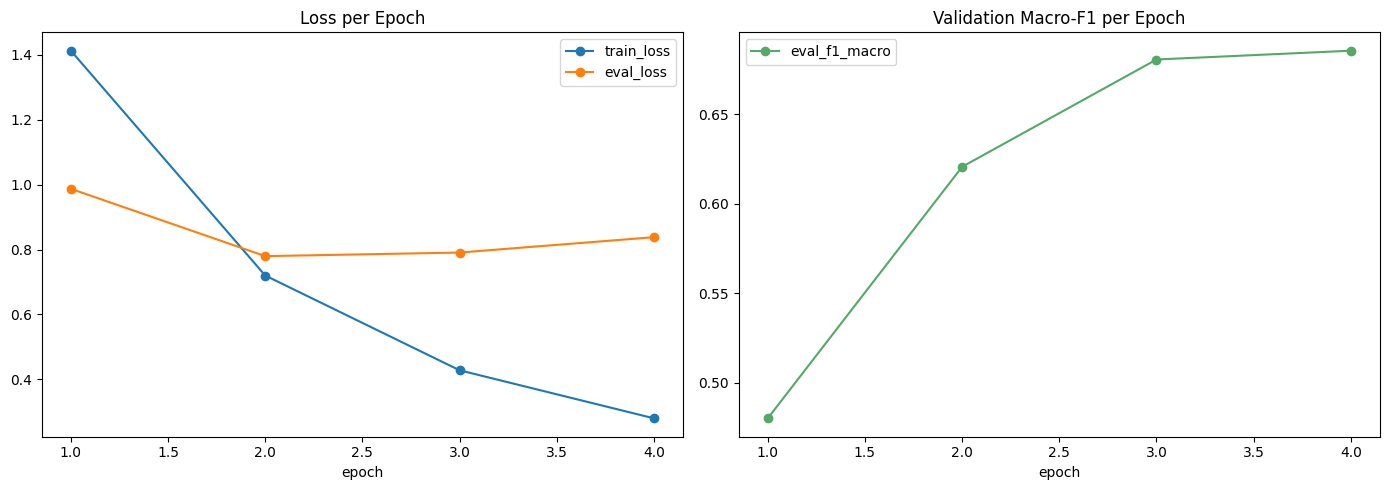

In [34]:
log_history = trainer.state.log_history

train_loss = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e]
eval_loss = [(e["epoch"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
eval_f1 = [(e["epoch"], e["eval_f1_macro"]) for e in log_history if "eval_f1_macro" in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if train_loss:
    axes[0].plot(*zip(*train_loss), label="train_loss", marker="o")
if eval_loss:
    axes[0].plot(*zip(*eval_loss), label="eval_loss", marker="o")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("epoch"); axes[0].legend()

if eval_f1:
    axes[1].plot(*zip(*eval_f1), label="eval_f1_macro", marker="o", color="#55A868")
axes[1].set_title("Validation Macro-F1 per Epoch")
axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_TRAINING_DIR / "layer2_training_curves.png", dpi=150)
plt.show()

### 12.1 Per-Class F1 Over Training

Worth tracking individually -- a rising macro-F1 could still hide a stagnant `TOPIC_SERV`.

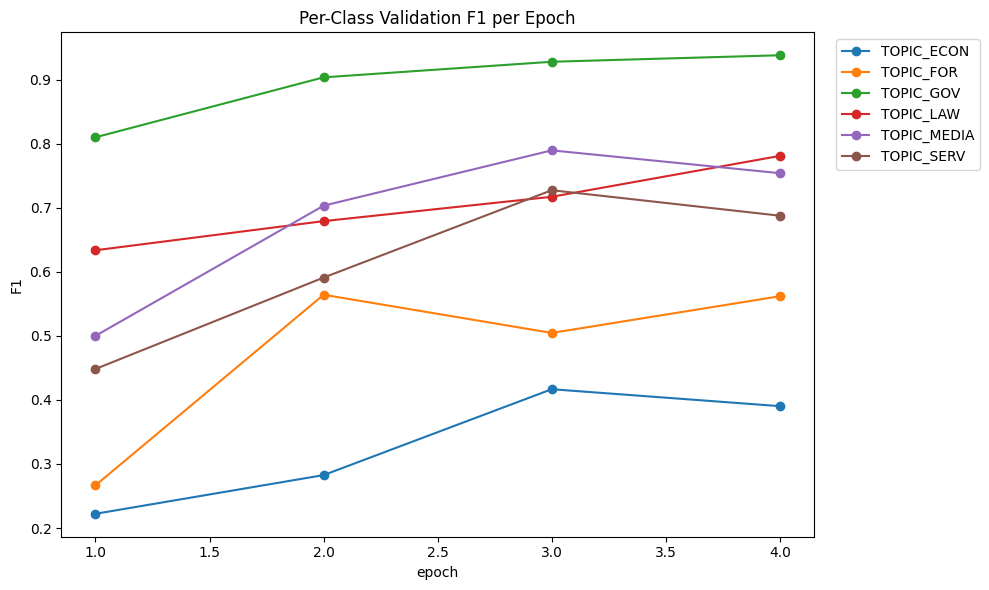

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
for label in LAYER2_LABELS:
    key = f"eval_f1_{label}"
    series = [(e["epoch"], e[key]) for e in log_history if key in e]
    if series:
        ax.plot(*zip(*series), label=label, marker="o")

ax.set_title("Per-Class Validation F1 per Epoch")
ax.set_xlabel("epoch"); ax.set_ylabel("F1")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_TRAINING_DIR / "layer2_per_class_f1_curves.png", dpi=150)
plt.show()

## 13. Save the Promoted Checkpoint

Only the best epoch (by validation macro-F1) is promoted, matching the Layer 1 convention.

In [36]:
best_model_dir = CHECKPOINTS_DIR / "best_model"
best_model_dir.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))

metadata = {
    "base_model": MODEL_NAME,
    "num_labels": len(LAYER2_LABELS),
    "max_seq_length": MAX_SEQ_LENGTH,
    "best_metric": "f1_macro",
    "best_metric_value": trainer.state.best_metric,
    "class_weights_used": class_weights_dict,
    "weighting_note": "Weights computed from post-oversampling train distribution, not pre-oversampling -- see Section 6",
    "random_seed": RANDOM_STATE,
    "train_rows": len(train_df),
    "val_rows": len(val_df),
}
with open(MODEL_DIR / "training_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Promoted checkpoint saved to:", best_model_dir.resolve())
print("Best validation macro-F1:", trainer.state.best_metric)

Promoted checkpoint saved to: /content/drive/MyDrive/public-pulse-srilanka-main/models/layer2_topic/checkpoints/best_model
Best validation macro-F1: 0.6853518709719536


## 14. Validation Set Sanity Check

**Not the final evaluation** — `03_evaluation.ipynb` owns that, against the untouched
test set. This is a directional check on the validation set the training process already
used for model selection.

In [37]:
val_predictions = trainer.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=-1)
val_labels = val_predictions.label_ids

print(classification_report(
    val_labels, val_preds,
    labels=list(range(len(LAYER2_LABELS))),
    target_names=LAYER2_LABELS,
    zero_division=0,
))

              precision    recall  f1-score   support

  TOPIC_ECON       0.44      0.35      0.39        23
   TOPIC_FOR       0.51      0.62      0.56        40
   TOPIC_GOV       0.95      0.92      0.94       950
   TOPIC_LAW       0.73      0.84      0.78        68
 TOPIC_MEDIA       0.68      0.84      0.75        58
  TOPIC_SERV       0.61      0.79      0.69        14

    accuracy                           0.89      1153
   macro avg       0.66      0.73      0.69      1153
weighted avg       0.90      0.89      0.89      1153



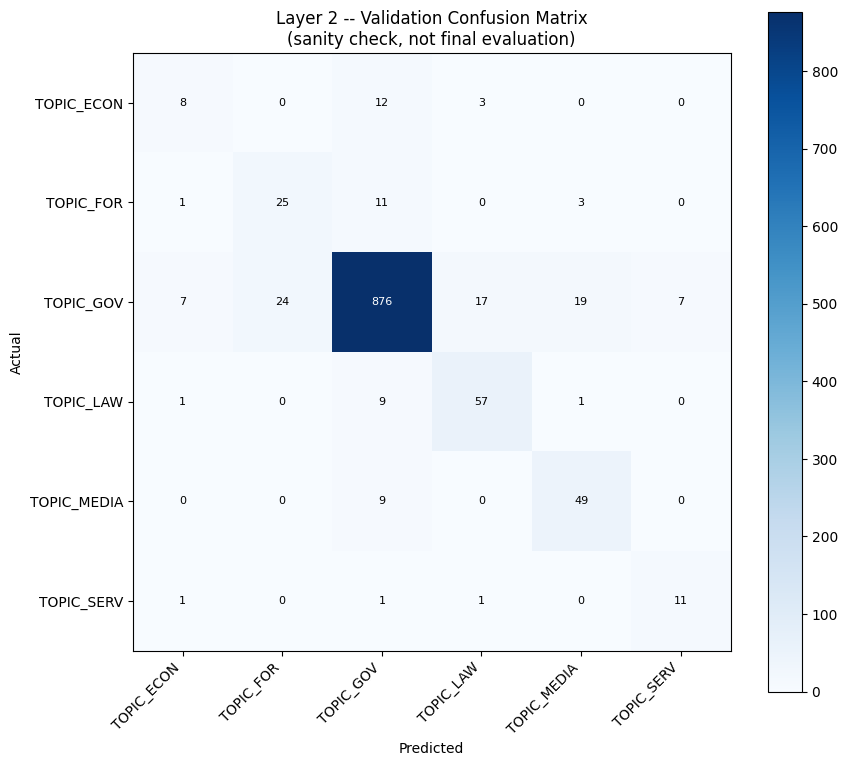

In [38]:
cm = confusion_matrix(val_labels, val_preds, labels=list(range(len(LAYER2_LABELS))))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LAYER2_LABELS))); ax.set_xticklabels(LAYER2_LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LAYER2_LABELS))); ax.set_yticklabels(LAYER2_LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Layer 2 -- Validation Confusion Matrix\n(sanity check, not final evaluation)")

for i in range(len(LAYER2_LABELS)):
    for j in range(len(LAYER2_LABELS)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)

plt.colorbar(im)
plt.tight_layout()
plt.savefig(RESULTS_CM_DIR / "layer2_validation_confusion_matrix.png", dpi=150)
plt.show()

## 15. Notebook Summary

### What was done
1. Loaded the oversampled train set and untouched validation set from `01_data_preparation.ipynb`
2. **Corrected a design flaw from the data-prep notebook's handover notes**: computed
   class weights from the post-oversampling distribution instead of the pre-oversampling
   one, avoiding a double-correction of the same imbalance
3. Built a `WeightedLossTrainer` subclass applying these weights via a standard
   `CrossEntropyLoss(weight=...)` override
4. Fine-tuned `xlm-roberta-base` (6-way head) for 4 epochs, selecting the best checkpoint
   by validation macro-F1
5. Tracked per-class F1 across training, not just the macro average
6. Saved the promoted checkpoint, label map, and full training metadata (including which
   class weights were actually used) for traceability
7. Ran a validation-set sanity check — full classification report and 6x6 confusion matrix

### Outputs produced
| File | Contents |
|---|---|
| `models/layer2_topic/checkpoints/best_model/` | Promoted checkpoint |
| `models/layer2_topic/label_map.json` | 6-class label map |
| `models/layer2_topic/class_weights_used.json` | The correctly-computed weights actually applied |
| `models/layer2_topic/training_metadata.json` | Full training config + metric for traceability |
| `results/training_curves/layer2_*.png` | Loss, macro-F1, and per-class F1 curves |
| `results/confusion_matrices/layer2_validation_confusion_matrix.png` | 6x6 validation confusion matrix |

### Key results
[Fill in after running: best validation macro-F1, per-class F1 for all 6 topics
(particularly `TOPIC_SERV`/`TOPIC_ECON`/`TOPIC_FOR`), training time and device used.]

## 16. Handover Notes — For the `03_evaluation.ipynb` Owner

**What to load:**
```python
model = AutoModelForSequenceClassification.from_pretrained("models/layer2_topic/checkpoints/best_model")
tokenizer = AutoTokenizer.from_pretrained("models/layer2_topic/checkpoints/best_model")
```
Label map: `models/layer2_topic/label_map.json`. 6 classes — `NULL` is **not** one of
them (see `01_data_preparation.ipynb` Section 3.2: zero `NULL` examples exist in this
dataset, so the model cannot predict it).

**What to evaluate against:** `data/splits/layer2/test.csv` — untouched by both this
notebook and `01_data_preparation.ipynb`.

**What to expect, stated honestly in advance:** `TOPIC_GOV` and likely `TOPIC_LAW` should
perform well. `TOPIC_MEDIA`, `TOPIC_FOR`, `TOPIC_ECON`, and especially `TOPIC_SERV` are
expected to underperform — this was a known, documented data-volume limitation before
training even started (see `01_data_preparation.ipynb` Section 7), not a surprise to
investigate as if something went wrong. If `TOPIC_SERV`'s test F1 is very low despite
both oversampling and weighted loss, that's expected confirmation the class needs
supplementary data collection, not evidence this training run was flawed.

**Known open items carried forward:**
- Layer 2 has no way to predict `NULL` — worth deciding at the inference/cascade level
  whether low-confidence predictions across all 6 classes should be treated as an
  implicit `NULL` at a later stage, since the model itself was never given that option.
- `TOPIC_SERV` showed the highest code-switching rate of any topic in
  `01_data_preparation.ipynb`'s diagnostics (14.7%) — if its performance is poor, check
  whether errors concentrate in code-switched examples specifically, which would suggest
  a linguistic difficulty compounding the data-volume problem, not just the volume
  problem alone.